# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**

1. Множество выпукло: это надграфик выпуклой функции $x_1 \mapsto x_1^2$. Действительно, для $x,y$ из множества и $t\in[0,1]$ имеем $((1-t)x_1+ty_1)^2\le(1-t)x_1^2+ty_1^2\le(1-t)x_2+ty_2$.
2. Множество выпукло как аффинный прообраз единичного евклидова шара. Также непосредственно: $\|A((1-t)x+ty)-b\|_2\le(1-t)\|Ax-b\|_2+t\|Ay-b\|_2\le1$.
3. Множество не выпукло. Точки $x=(1,0)$ и $y=(-1,0)$ принадлежат ему, но их середина $(0,0)$ не принадлежит.

**(б)**

**Ответ:**

1. Гессиан $f$ постоянен: $H=\begin{pmatrix}2&a\\a&2\end{pmatrix}$, его собственные числа равны $2-a$ и $2+a$. Поэтому $f$ выпукла при $|a|\le2$ и строго выпукла при $|a|<2$. При $|a|=2$ гессиан вырожден и вдоль ненулевого направления функция постоянна, поэтому строгой выпуклости нет.
2. Для $g(x)=x_1^2x_2^2$ имеем $\nabla^2g(x)=\begin{pmatrix}2x_2^2&4x_1x_2\\4x_1x_2&2x_1^2\end{pmatrix}$. В точке $(1,1)$ его собственные числа равны $-2$ и $6$, то есть гессиан не положительно полуопределён. Следовательно, $g$ не выпукла на $\mathbb R^2$.

In [10]:
for a_value in [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    H = np.array([[2.0, a_value], [a_value, 2.0]])
    eigenvalues = np.linalg.eigvalsh(H)
    print(f"a = {a_value:4.1f}: собственные значения: {eigenvalues}")

Hg_at_11 = np.array([[2.0, 4.0], [4.0, 2.0]])
eigenvalues_g = np.linalg.eigvalsh(Hg_at_11)

print(
    "Собственные значения гессиана функции g "
    "в точке (1, 1):",
    eigenvalues_g,
)

a = -3.0: собственные значения: [-1.  5.]
a = -2.0: собственные значения: [0. 4.]
a = -1.0: собственные значения: [1. 3.]
a =  0.0: собственные значения: [2. 2.]
a =  1.0: собственные значения: [1. 3.]
a =  2.0: собственные значения: [0. 4.]
a =  3.0: собственные значения: [-1.  5.]
Собственные значения гессиана функции g в точке (1, 1): [-2.  6.]


**(в)**

**Ответ:**

1. Обе функции $x\mapsto\|Ax-b\|_2$ и $x\mapsto\|x\|_\infty$ выпуклы (норма после аффинного отображения и норма соответственно). Их сумма с неотрицательным коэффициентом $\lambda$ выпукла. В общем случае функция негладкая: первая норма не дифференцируема при $Ax-b=0$, а $\|x\|_\infty$ — в точках с несколькими максимальными по модулю координатами (в частности, в нуле).
2. Каждая функция $(a_i^\top x-b_i)^2$ выпукла, поскольку её гессиан $2a_i a_i^\top\succeq0$. Поточечный максимум выпуклых функций выпукл. В общем случае максимум негладок в точках, где максимум одновременно достигается несколькими ветвями с различными градиентами.
3. Правило композиции не применимо: внешняя экспонента выпукла и возрастает, но внутренняя функция $-\|x\|_2^2$ вогнута, а не выпукла и не аффинна. Более того, $\nabla^2 f(x)=e^{-\|x\|^2}(4xx^\top-2I)$, поэтому $\nabla^2f(0)=-2I\prec0$ и функция не выпукла. Эта функция гладкая ($C^\infty$).

Итак, третья функция гладкая; первые две в общем случае негладкие (хотя в вырожденных частных случаях отдельные точки негладкости могут исчезнуть).

**(г)**

**Ответ:**

1. **(а), линейный МНК:** выпуклая безусловная задача. Цель $\tfrac12\|Ax-b\|_2^2$ имеет гессиан $A^\top A\succeq0$; равенств и неравенств нет.
2. **(б), планирование производства:** выпуклая задача (LP): цель аффинна, все ограничения — аффинные равенства или неравенства.
3. **(в), цепь с полом:** выпуклая задача: квадратичная энергия имеет положительно определённый гессиан, а ограничения пола линейны; нелинейных равенств нет.
4. **(г), подгонка $x_1\sin(x_2t+x_3)$:** невыпуклая нелинейная задача МНК. Ограничений нет, но цель невыпукла из-за нелинейной зависимости невязок от частоты и фазы; периодичность по $x_3$ и симметрия $(x_1,x_3)\mapsto(-x_1,x_3+\pi)$ создают разные эквивалентные точки и локальные минимумы.
5. **Бонус (д), чебышёвская подгонка:** выпуклая задача. Цель $\max_i|a_i^\top x-b_i|$ — максимум выпуклых модулей аффинных функций; ограничений нет. Эквивалентная эпиграфическая запись с переменной $s$ и ограничениями $-s\le a_i^\top x-b_i\le s$ является LP.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:**

Здесь $f(x)=\tfrac12\|x-p\|^2$ и $\nabla f(x)=x-p$. Если бы $x^\ast$ лежала строго внутри $\Omega$, то вместе с ней были бы допустимы малые шаги во всех направлениях. Условие оптимальности для противоположных направлений дало бы $x^\ast-p=0$, то есть $x^\ast=p$, что невозможно, поскольку $p\notin\Omega$. Значит, $a^\top x^\ast=b$.

Для любого $v$ с $a^\top v=0$ точки $x^\ast+v$ и $x^\ast-v$ лежат на границе и допустимы. Условие оптимальности для них даёт одновременно $(x^\ast-p)^\top v\ge0$ и $-(x^\ast-p)^\top v\ge0$, поэтому $(x^\ast-p)^\top v=0$ для всех $v\perp a$. Следовательно, $x^\ast-p=\mu a$. Из равенства на границе
$$a^\top p+\mu\|a\|^2=b,\qquad \mu=-\frac{a^\top p-b}{\|a\|^2},$$
и потому
$$x^\ast=p-\frac{a^\top p-b}{\|a\|^2}a.$$
Обозначим $\alpha=(a^\top p-b)/\|a\|^2>0$. Для любого $y\in\Omega$ получаем
$$(x^\ast-p)^\top(y-x^\ast)=-\alpha a^\top(y-x^\ast)=\alpha(b-a^\top y)\ge0.$$
Таким образом, найденная точка удовлетворяет достаточному условию оптимальности выпуклой задачи и действительно является единственной проекцией.

**Численная проверка (пункты 2 и 3)**

In [11]:
x_formula = p - (a @ p - b) / (a @ a) * a

result = minimize(
    lambda x: 0.5 * np.sum((x - p) ** 2),
    x0=np.zeros_like(p),
    method="SLSQP",
    constraints={"type": "ineq","fun": lambda x: b - a @ x,},
    options={"ftol": 1e-12,"maxiter": 1000,},
)

print("Проекция по формуле:", x_formula)
print("Проекция, найденная методом SLSQP:", result.x)
print("Норма разности результатов:", np.linalg.norm(result.x - x_formula),)
print("Невязка граничного условия a @ x* - b:", a @ x_formula - b,)

# Генерируем случайные точки и проецируем их на полупространство,
# чтобы получить допустимые точки y.
Y = rng.normal(size=(2000, p.size)) * 3.0
violations = np.maximum(Y @ a - b, 0.0)
Y -= (violations / (a @ a))[:, None] * a

min_at_optimum = np.min((Y - x_formula) @ (x_formula - p))
min_at_zero = np.min(Y @ (-p))

print("Минимальное значение условия оптимальности в точке x*:", min_at_optimum,)
print("Минимальное значение условия оптимальности в точке x = 0:", min_at_zero,)

Проекция по формуле: [ 2.41666667 -0.16666667  1.08333333]
Проекция, найденная методом SLSQP: [ 2.41666667 -0.16666667  1.08333333]
Норма разности результатов: 0.0
Невязка граничного условия a @ x* - b: -4.440892098500626e-16
Минимальное значение условия оптимальности в точке x*: -2.4627874552111035e-15
Минимальное значение условия оптимальности в точке x = 0: -29.671308073665216


**Ответ:**

Явная формула даёт $x^\ast=(2.4166667,-0.1666667,1.0833333)$. Результат SLSQP совпадает с ней с точностью численного решателя. В оптимальной точке минимум скалярного произведения неотрицателен с учётом ошибки округления: это численный сертификат условия оптимальности. Для допустимой, но неоптимальной точки $x=0$ минимум отрицателен; значит, существует допустимое направление $y-x$, вдоль которого целевая функция убывает в первом порядке.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

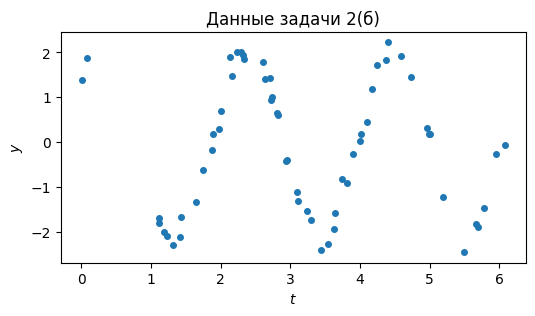

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:**

Модель A задаёт безусловную нелинейную задачу наименьших квадратов. Она невыпукла: цель непостоянна и периодична по фазе, $f(x_1,x_2,x_3+2\pi)=f(x_1,x_2,x_3)$, тогда как непостоянная выпуклая функция на прямой не может быть периодической. Кроме того, преобразование $(x_1,x_3)\mapsto(-x_1,x_3+\pi)$ не меняет сигнал и создаёт разнесённые эквивалентные решения; множество решений выпуклой задачи должно быть выпуклым.

Модель B — линейный МНК. Если $X_{i1}=\sin(\omega t_i)$ и $X_{i2}=\cos(\omega t_i)$, то $f_B(x)=\tfrac12\|Xx-y\|^2$, а $\nabla^2f_B=X^\top X\succeq0$. Поэтому задача выпукла; для данных ниже столбцы $X$ линейно независимы, так что $X^\top X\succ0$, цель строго выпукла и решение единственно.

**Мультистарт (пункт 2)**

Итоги f для A: [ 1.139273 63.824905  1.139273  1.139273  1.139273 61.497273 61.497273
 64.251776  1.139273 63.824904  1.139273  1.139273 61.497273  1.139273
 64.251776  1.139273 61.688171  1.139273 61.497273  1.139273]
Доля стартов, приведших к наименьшему A: 0.55
Лучшие значения для A: [-2.10139254  2.9966906  -2.44132862]
Итоги f для B: [1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764
 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764
 1.140764 1.140764 1.140764 1.140764]
Доля стартов, приведших к наименьшему B: 1.0
Лучшие значения для B: [1.62342689 1.33780773]


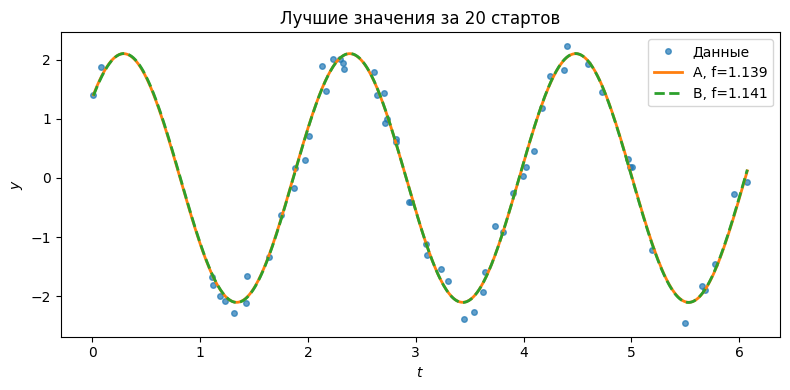

In [6]:
X = np.column_stack((np.sin(omega * t), np.cos(omega * t)))

results_A = []
results_B = []
for start in starts:
    result_A = minimize(
        lambda x: 0.5 * np.sum((x[0] * np.sin(x[1] * t + x[2]) - y) ** 2),
        start, method="BFGS",
    )
    result_B = minimize(
        lambda x: 0.5 * np.sum((X @ x - y) ** 2),
        start[:2], method="BFGS",
    )
    results_A.append(result_A)
    results_B.append(result_B)

values_A = np.array([res.fun for res in results_A])
values_B = np.array([res.fun for res in results_B])
best_A = results_A[np.argmin(values_A)]
best_B = results_B[np.argmin(values_B)]

print("Итоги f для A:", np.round(values_A, 6))
print("Доля стартов, приведших к наименьшему A:", np.mean(np.isclose(values_A, values_A.min(), rtol=1e-5, atol=1e-7)))
print("Лучшие значения для A:", best_A.x)
print("Итоги f для B:", np.round(values_B, 6))
print("Доля стартов, приведших к наименьшему B:", np.mean(np.isclose(values_B, values_B.min(), rtol=1e-5, atol=1e-7)))
print("Лучшие значения для B:", best_B.x)

t_grid = np.linspace(t.min(), t.max(), 1000)
prediction_A = best_A.x[0] * np.sin(best_A.x[1] * t_grid + best_A.x[2])
prediction_B = (
    best_B.x[0] * np.sin(omega * t_grid)
    + best_B.x[1] * np.cos(omega * t_grid)
)
plt.figure(figsize=(8, 4))
plt.plot(t, y, "o", ms=4, alpha=0.7, label="Данные")
plt.plot(t_grid, prediction_A, lw=2, label=f"A, f={best_A.fun:.3f}")
plt.plot(t_grid, prediction_B, "--", lw=2, label=f"B, f={best_B.fun:.3f}")
plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("Лучшие значения за 20 стартов")
plt.legend()
plt.tight_layout()
plt.show()

**Объяснение (пункт 3)**

**Ответ:**

По главной теореме лекции любой локальный минимум выпуклой задачи B глобален. Поэтому все старты BFGS для B приходят к одному значению (различия возможны лишь на уровне допуска). Для невыпуклой A такой гарантии нет: разные старты попадают в разные локальные минимумы, что видно по итоговым значениям цели.

Если решение B равно $(c_1,c_2)$, то
$$c_1\sin(\omega t)+c_2\cos(\omega t)=R\sin(\omega t+\phi),$$
где $R=\sqrt{c_1^2+c_2^2}$ и $\phi=\operatorname{atan2}(c_2,c_1)$ (по модулю $2\pi$). Это даёт параметры A: $(R,\omega,\phi)$.

У A на один свободный параметр больше: она подбирает ещё и частоту, поэтому её наименьшее найденное значение $f$ может быть чуть меньше за счёт подгонки шума. Но более низкая обучающая ошибка не делает задачу вычислительно лучше: A невыпукла, зависит от старта и не даёт сертификата глобальности, тогда как B имеет единственное глобальное решение.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:**

Обозначим $u=P(p)$ и $v=P(q)$. Условие оптимальности для проекции $p$ с пробной точкой $v$ и для проекции $q$ с пробной точкой $u$ даёт
$$ (u-p)^\top(v-u)\ge0,\qquad (v-q)^\top(u-v)\ge0. $$
Положив $d=u-v$ и сложив неравенства, получаем
$$((p-q)-d)^\top d\ge0,\qquad \|d\|^2\le(p-q)^\top d.$$
По неравенству Коши--Буняковского
$$\|d\|^2\le\|p-q\|\,\|d\|.$$
Если $d=0$, требуемое утверждение очевидно; иначе делим на $\|d\|$ и получаем $\|P(p)-P(q)\|\le\|p-q\|$.

In [7]:
pair_rng = np.random.default_rng(2026)
n, pair_count = 5, 1000
P = pair_rng.normal(size=(pair_count, n)) * 3.0
Q = pair_rng.normal(size=(pair_count, n)) * 3.0

input_distances = np.linalg.norm(P - Q, axis=1)
P_ball = P / np.maximum(1.0, np.linalg.norm(P, axis=1, keepdims=True))
Q_ball = Q / np.maximum(1.0, np.linalg.norm(Q, axis=1, keepdims=True))
P_cube = np.clip(P, -1.0, 1.0)
Q_cube = np.clip(Q, -1.0, 1.0)

for name, projected_P, projected_Q in [
    ("Единичный шар", P_ball, Q_ball),
    ("Куб", P_cube, Q_cube),
]:
    output_distances = np.linalg.norm(projected_P - projected_Q, axis=1)
    ratios = np.divide(
        output_distances, input_distances,
        out=np.zeros_like(output_distances), where=input_distances > 0,
    )
    print(
        f"{name}: относительное изменение = {ratios.max():.4f}, "
        f"абсолютная разница = {(output_distances - input_distances).max():.3e}",
    )
    assert np.all(output_distances <= input_distances + 1e-12)

Единичный шар: относительное изменение = 0.4399, абсолютная разница = -1.692e+00
Куб: относительное изменение = 0.8196, абсолютная разница = -3.919e-01
